!/usr/bin/env python
coding: utf-8

# InstaClone k6 Benchmark Results Analysis

Sections:

1. **Summary JSON** — aggregate stats from any completed run.
2. **Raw JSON lines** — time-series response time vs VU count, per-scenario breakdown.
   - 2b. **System metrics overlay** — CPU %, memory and DB connections over time.
3. **Multi-run comparison** — compare runs across scaling/config changes.

Set the paths in the **Configuration** cell below, then run all cells.

In [20]:
# -- Configuration -------------------------------------------------------------
# Point RESULTS_DIR at any results/<timestamp>_<profile>/ folder.

from pathlib import Path

RESULTS_DIR = Path("results/20260310_210727_stress")  # ← change me

# Raw JSON lines file produced by -o json=FILE (supports .gz).
# Example: RESULTS_DIR / "02_posting_heavy_raw.json.gz"
RAW_FILE = Path(
    "results/20260310_210727_stress/05_newsfeed_algorithms_raw.json.gz"
)  # ← change me

# Sysmetrics CSV produced by collect_sysmetrics.sh (set to None to skip Section 2b).
# Example: RESULTS_DIR / "02_posting_heavy_sysmetrics.csv"
SYSMETRICS_FILE = None  # ← change me

# Metric to use as the primary latency axis in Section 2.
# Options: 'http_req_duration', 'post_create_duration', 'login_duration', …
PRIMARY_METRIC = "http_req_duration"

In [21]:
# -- Imports -------------------------------------------------------------------
import json, gzip, math, re, csv
from collections import defaultdict
from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

# 'display' is a Jupyter IPython builtin; fall back to print when running as a script
display = print  # default; overridden by IPython kernel at runtime
try:
    from IPython.display import display  # type: ignore[assignment]
except ImportError:
    pass


matplotlib.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.35,
        "font.size": 11,
    }
)
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

print(
    f"pandas {pd.__version__}  |  matplotlib {matplotlib.__version__}  |  numpy {np.__version__}"
)


# ---
# ## Section 1 — Summary JSON: aggregate stats across all benchmarks
#
# Works with any `*_summary.json` file from `run_single.sh` / `run_all.sh`.

pandas 2.3.1  |  matplotlib 3.10.5  |  numpy 2.3.4


In [22]:
# -- Load all summary JSONs in RESULTS_DIR -------------------------------------

METRIC_MAP = {
    "01_auth_login": "login_duration",
    "02_posting_heavy": "post_create_duration",
    "03_likes_comments_reports": "like_duration",
    "04_personalized_ads": "feed_with_ads_duration",
    "05_newsfeed_algorithms": "algo1_time_based_duration",
    "06_analytics_dashboard": "analytics_duration",
    "07_workbook_teacher": "section_list_duration",
    "08_workbook_student": "section_browse_duration",
}


def load_summaries(results_dir):
    rows = []
    for f in sorted(Path(results_dir).glob("*_summary.json")):
        bench = f.stem.replace("_summary", "")
        with open(f) as fh:
            data = json.load(fh)
        metrics = data.get("metrics", {})
        primary_name = METRIC_MAP.get(bench, "http_req_duration")
        primary = metrics.get(primary_name) or metrics.get("http_req_duration", {})
        http_dur = metrics.get("http_req_duration", {})
        http_fail = metrics.get("http_req_failed", {})
        http_reqs = metrics.get("http_reqs", {})

        thresh_results = {}
        for mname, mdata in metrics.items():
            if isinstance(mdata, dict) and "thresholds" in mdata:
                for tname, passed in mdata["thresholds"].items():
                    thresh_results[f"{mname}: {tname}"] = passed
        all_pass = all(thresh_results.values()) if thresh_results else None

        rows.append(
            {
                "benchmark": bench,
                "primary_metric": primary_name,
                "p50_ms": primary.get("med", 0),
                "p90_ms": primary.get("p(90)", 0),
                "p95_ms": primary.get("p(95)", 0),
                "avg_ms": primary.get("avg", 0),
                "max_ms": primary.get("max", 0),
                "http_p95_ms": http_dur.get("p(95)", 0),
                "error_rate": http_fail.get("rate", http_fail.get("value", 0)),
                "total_reqs": http_reqs.get("count", http_reqs.get("value", 0)),
                "rps": http_reqs.get("rate", 0),
                "thresholds_ok": all_pass,
                "threshold_detail": thresh_results,
            }
        )
    return pd.DataFrame(rows)


df_summary = load_summaries(RESULTS_DIR)
print(f"Loaded {len(df_summary)} benchmarks from {RESULTS_DIR}")
# x and short_names are populated inside the 'if not df_summary.empty' blocks below
x: "np.ndarray" = np.array([])
short_names: list = []
df_summary[
    [
        "benchmark",
        "primary_metric",
        "p50_ms",
        "p95_ms",
        "error_rate",
        "total_reqs",
        "thresholds_ok",
    ]
]

Loaded 8 benchmarks from results/20260310_210727_stress


,benchmark,primary_metric,p50_ms,p95_ms,error_rate,total_reqs,thresholds_ok
0,01_auth_login,login_duration,4970.0,12386.50,0.000000,8118,False
1,02_posting_heavy,post_create_duration,4612.5,16349.55,0.000000,5638,False
2,03_likes_comments_reports,like_duration,648.0,1742.00,0.005776,42241,False
3,04_personalized_ads,feed_with_ads_duration,7079.0,21524.45,0.043693,6889,False
4,05_newsfeed_algorithms,algo1_time_based_duration,9243.0,25880.20,0.000194,5155,False
5,06_analytics_dashboard,analytics_duration,1507.0,5750.00,0.000099,10111,False
6,07_workbook_teacher,section_list_duration,0.0,0.00,1.000000,1,False
7,08_workbook_student,section_browse_duration,178.0,861.00,0.000019,53950,False


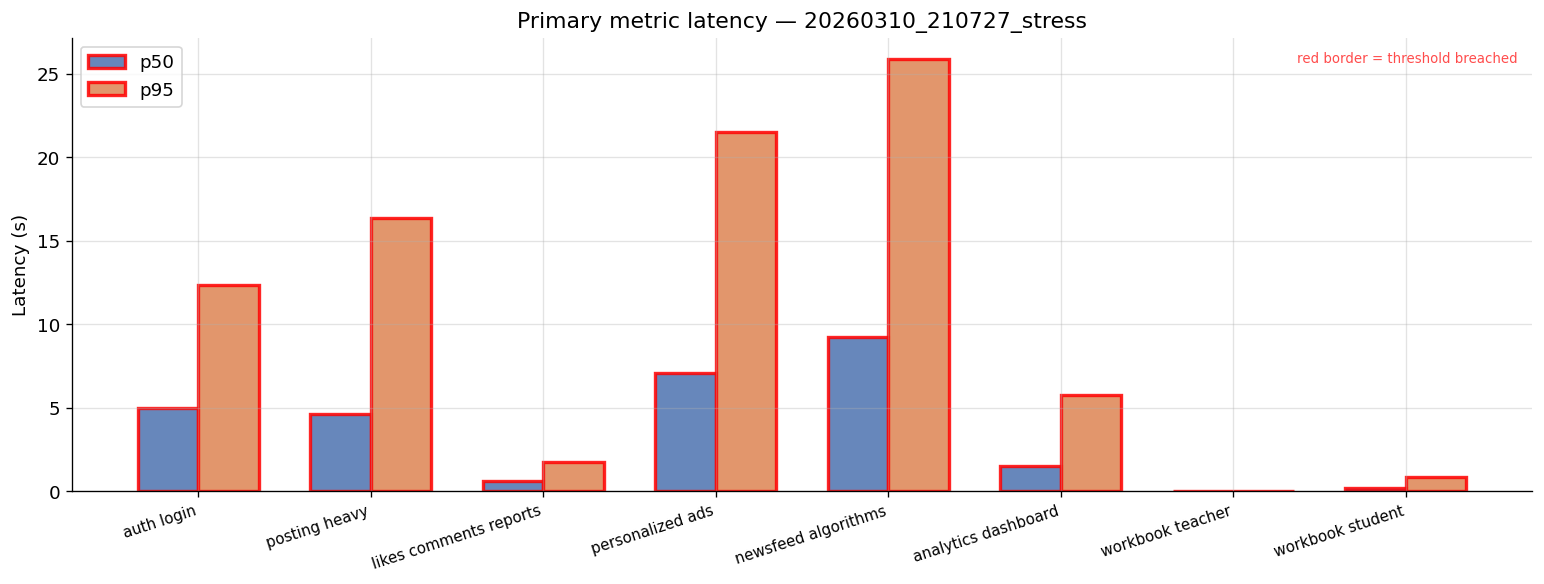

Saved → results/20260310_210727_stress/plot_latency_summary.png


In [23]:
# -- Plot 1: p50 / p95 latency per benchmark (primary custom metric) ------------

if df_summary.empty:
    print("No summary data found — check RESULTS_DIR.")
else:
    short_names = [
        b.split("_", 1)[1].replace("_", " ") for b in df_summary["benchmark"]
    ]
    x = np.arange(len(df_summary))
    w = 0.35

    fig, ax = plt.subplots(figsize=(13, 5))
    bars_p50 = ax.bar(
        x - w / 2,
        df_summary["p50_ms"] / 1000,
        w,
        label="p50",
        color=PALETTE[0],
        alpha=0.85,
    )
    bars_p95 = ax.bar(
        x + w / 2,
        df_summary["p95_ms"] / 1000,
        w,
        label="p95",
        color=PALETTE[1],
        alpha=0.85,
    )

    for idx, (_, row) in enumerate(df_summary.iterrows()):
        if row["thresholds_ok"] is False:
            bars_p50[idx].set_edgecolor("red")
            bars_p50[idx].set_linewidth(2)
            bars_p95[idx].set_edgecolor("red")
            bars_p95[idx].set_linewidth(2)

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=18, ha="right", fontsize=9)
    ax.set_ylabel("Latency (s)")
    ax.set_title(f"Primary metric latency — {RESULTS_DIR.name}")
    ax.legend()
    ax.text(
        0.99,
        0.97,
        "red border = threshold breached",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="red",
        alpha=0.7,
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "plot_latency_summary.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → {RESULTS_DIR}/plot_latency_summary.png")

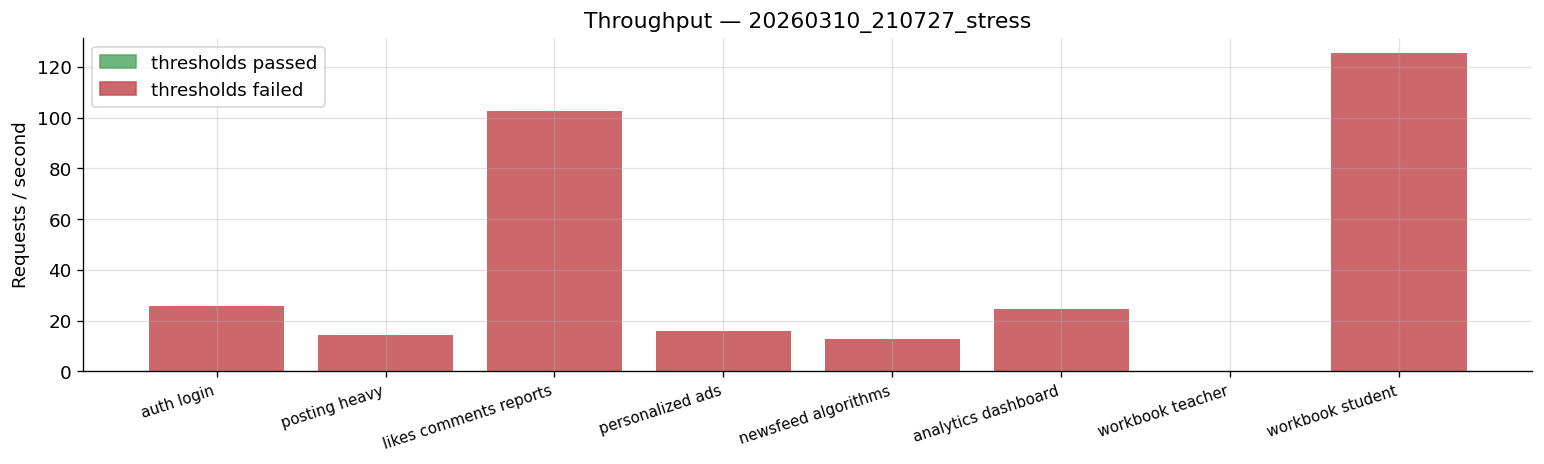

In [24]:
# -- Plot 2: throughput (req/s) per benchmark -----------------------------------

if not df_summary.empty:
    fig, ax = plt.subplots(figsize=(13, 4))
    colors = [
        PALETTE[2] if ok else PALETTE[3]
        for ok in df_summary["thresholds_ok"].fillna(True)
    ]
    ax.bar(x, df_summary["rps"], color=colors, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=18, ha="right", fontsize=9)
    ax.set_ylabel("Requests / second")
    ax.set_title(f"Throughput — {RESULTS_DIR.name}")
    green_p = mpatches.Patch(color=PALETTE[2], alpha=0.85, label="thresholds passed")
    red_p = mpatches.Patch(color=PALETTE[3], alpha=0.85, label="thresholds failed")
    ax.legend(handles=[green_p, red_p])
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "plot_throughput_summary.png", bbox_inches="tight")
    plt.show()

In [25]:
# -- Table: threshold detail ----------------------------------------------------

if not df_summary.empty:
    rows = []
    for _, r in df_summary.iterrows():
        for tname, passed in r["threshold_detail"].items():
            rows.append(
                {
                    "benchmark": r["benchmark"],
                    "threshold": tname,
                    "passed": "✓" if passed else "✗",
                }
            )
    df_thresh = pd.DataFrame(rows)
    if not df_thresh.empty:
        pd.set_option("display.max_colwidth", 60)
        display(
            df_thresh.style.map(
                lambda v: "color: green"
                if v == "✓"
                else ("color: red" if v == "✗" else ""),
                subset=["passed"],
            )
        )


# ---
# ## Section 2 — Raw JSON lines: response time vs VUs over time
#
# Requires a run with `-o json=FILE` (produced automatically by the runner scripts).
# Set `RAW_FILE` in the Configuration cell and re-run from here.
#
# ### What this shows
# - **Panel 1**: p50 / p95 latency rolling over time (10-second windows)
# - **Panel 2**: active VU count over time with scenario shading
# - **Per-scenario table**: p50 / p90 / p95 / p99 and req/s by VU level

,benchmark,threshold,passed
0,01_auth_login,login_duration: p(95)<800,✓
1,01_auth_login,profile_duration: p(95)<400,✓
2,01_auth_login,http_req_failed: rate<0.10,✗
3,01_auth_login,http_req_duration: p(95)<5000,✓
4,01_auth_login,login_fail_rate: rate<0.01,✗
5,02_posting_heavy,post_create_duration: p(95)<1500,✓
6,02_posting_heavy,feed_refresh_duration: p(95)<1000,✓
7,02_posting_heavy,http_req_failed: rate<0.10,✗
8,02_posting_heavy,http_req_duration: p(95)<5000,✓
9,02_posting_heavy,post_fail_rate: rate<0.01,✗


In [26]:
# -- Load raw JSON lines --------------------------------------------------------


def open_raw(path):
    p = Path(path)
    if p.suffix == ".gz" or str(p).endswith(".json.gz"):
        return gzip.open(p, "rt", encoding="utf-8")
    return open(p, "r", encoding="utf-8")


def parse_raw(path, metric_name="http_req_duration"):
    """
    Returns three DataFrames:
      df_dur  — one row per duration sample: timestamp, value_ms, scenario
      df_vus  — one row per VU-count sample: timestamp, value
      df_fail — one row per http_req_failed sample: timestamp, value, scenario
    """
    dur_rows = []
    vus_rows = []
    fail_rows = []

    with open_raw(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            if obj.get("type") != "Point":
                continue

            m = obj.get("metric", "")
            data = obj.get("data", {})
            val = data.get("value", 0)
            tags = data.get("tags", {})
            ts = data.get("time", "")
            scenario = tags.get("scenario", "")

            try:
                t = datetime.datetime.fromisoformat(ts.replace("Z", "+00:00"))
            except Exception:
                continue

            if m == metric_name:
                dur_rows.append({"ts": t, "value_ms": val, "scenario": scenario})
            elif m == "vus":
                vus_rows.append({"ts": t, "vus": val})
            elif m == "http_req_failed":
                fail_rows.append({"ts": t, "failed": val, "scenario": scenario})

    def to_df(rows):
        if not rows:
            return pd.DataFrame()
        return pd.DataFrame(rows).sort_values("ts").reset_index(drop=True)

    return to_df(dur_rows), to_df(vus_rows), to_df(fail_rows)


# Shared geometry variables — populated below if RAW_FILE exists
t0 = None
sc_spans = {}
sc_color = {}
scenario_names = []
thresh_val = None
bench_key = ""
roll_t = []
roll_p95 = []

if RAW_FILE is None or not Path(RAW_FILE).exists():
    print("RAW_FILE is not set or not found — skipping Section 2.")
    df_dur = df_vus = df_fail = pd.DataFrame()
else:
    print(f"Parsing {RAW_FILE} …")
    df_dur, df_vus, df_fail = parse_raw(RAW_FILE, PRIMARY_METRIC)
    print(f"  duration samples : {len(df_dur):,}")
    print(f"  VU samples       : {len(df_vus):,}")
    print(f"  failure samples  : {len(df_fail):,}")
    if not df_dur.empty:
        print(f"  time range       : {df_dur['ts'].min()} → {df_dur['ts'].max()}")
        print(f"  scenarios        : {df_dur['scenario'].unique().tolist()}")

Parsing results/20260310_210727_stress/05_newsfeed_algorithms_raw.json.gz …
  duration samples : 5,155
  VU samples       : 402
  failure samples  : 5,155
  time range       : 2026-03-10 21:38:09.806437+01:00 → 2026-03-10 21:44:52.152041+01:00
  scenarios        : ['', 'newsfeed_compare_warmup', 'newsfeed_compare_50vu', 'newsfeed_compare_150vu', 'newsfeed_compare_300vu']


In [27]:
# -- Derived geometry (shared by all Section 2 / 2b plots) ---------------------

if not df_dur.empty:
    t0 = df_dur["ts"].min()
    df_dur["t"] = (df_dur["ts"] - t0).dt.total_seconds()
    if not df_vus.empty:
        df_vus["t"] = (df_vus["ts"] - t0).dt.total_seconds()

    scenarios_order = df_dur.groupby("scenario")["t"].min().sort_values()
    scenario_names = scenarios_order.index.tolist()
    sc_palette = PALETTE[: len(scenario_names)]
    sc_color = {
        s: sc_palette[i % len(sc_palette)] for i, s in enumerate(scenario_names)
    }

    sc_spans = {}
    for sc in scenario_names:
        sc_spans[sc] = (
            df_dur[df_dur["scenario"] == sc]["t"].min(),
            df_dur[df_dur["scenario"] == sc]["t"].max(),
        )

    # Extract p95 threshold from summary file
    bench_key = Path(str(RAW_FILE)).stem.replace("_raw", "").replace(".json", "")
    thresh_val = None
    summary_path = Path(str(RAW_FILE)).parent / f"{bench_key}_summary.json"
    if summary_path.exists():
        with open(summary_path) as fh:
            sd = json.load(fh)
        for mname, mdata in sd.get("metrics", {}).items():
            if mname == PRIMARY_METRIC and "thresholds" in mdata:
                for tname in mdata["thresholds"]:
                    m = re.search(r"p\(95\)<(\d+)", tname)
                    if m:
                        thresh_val = int(m.group(1))
    if thresh_val:
        print(f"  p95 threshold    : {thresh_val} ms")

    # Rolling percentiles (used by Plot 3 and Plot 8)
    df_dur_ts = df_dur.set_index("ts").sort_index()
    roll_p50 = df_dur_ts["value_ms"].resample("1s").median().rolling("10s").median()
    roll_p95 = (
        df_dur_ts["value_ms"]
        .resample("1s")
        .quantile(0.95)
        .rolling("10s")
        .quantile(0.95)
    )
    roll_t = [(ts - t0).total_seconds() for ts in roll_p50.index]

  p95 threshold    : 5000 ms


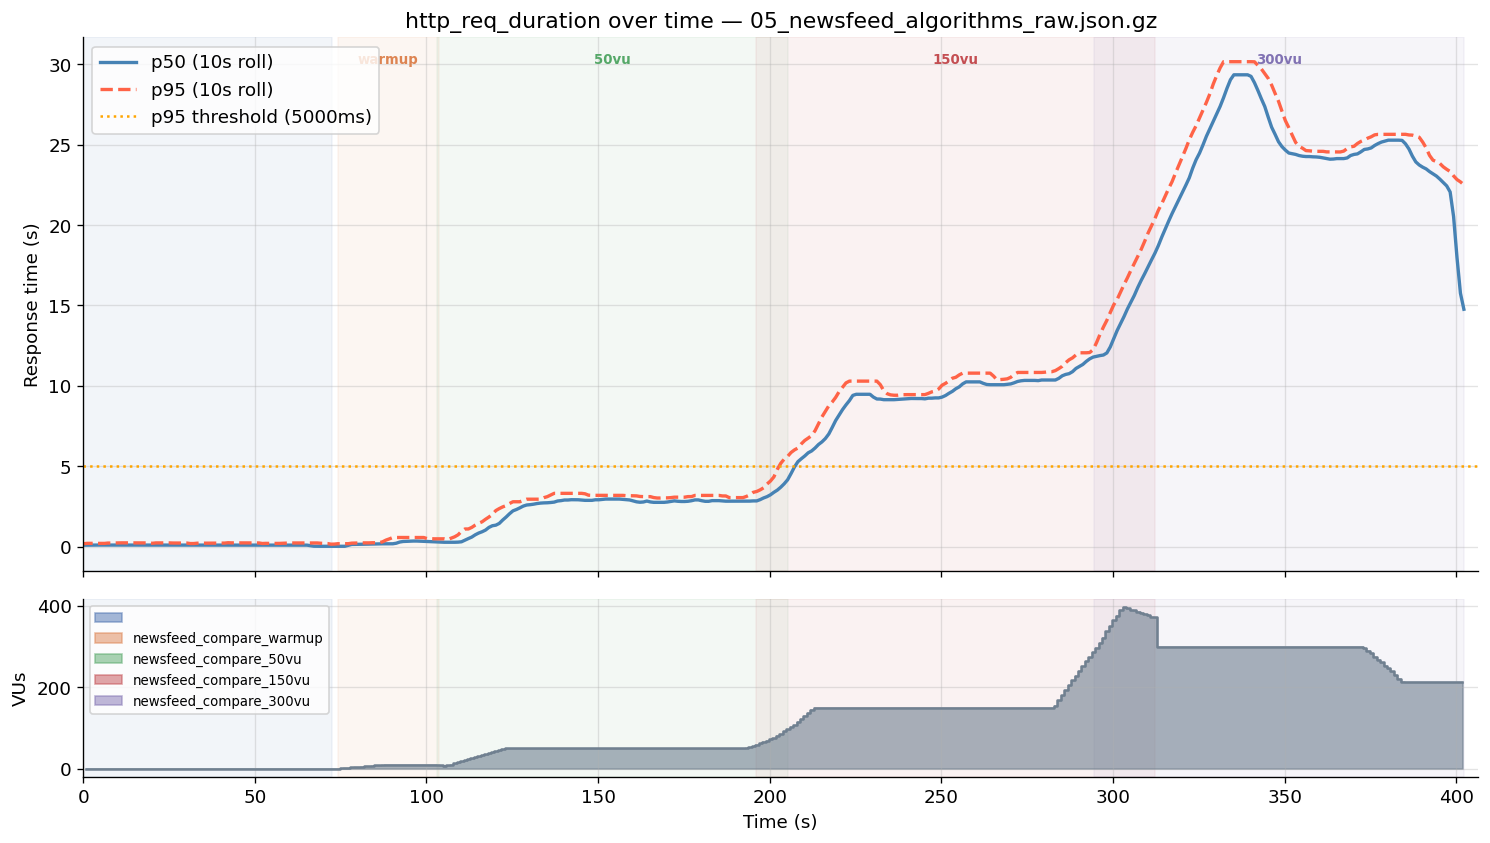

Saved → results/20260310_210727_stress/05_newsfeed_algorithms_latency_over_time.png


In [28]:
# -- Plot 3: Response time vs time + VU count (2-panel) ------------------------

if df_dur.empty:
    print("No duration data — set RAW_FILE and re-run this cell.")
else:
    total_t = df_dur["t"].max()

    fig = plt.figure(figsize=(15, 8))
    gs = GridSpec(2, 1, figure=fig, height_ratios=[3, 1], hspace=0.08)
    ax_lat = fig.add_subplot(gs[0])
    ax_vus = fig.add_subplot(gs[1], sharex=ax_lat)

    # Latency panel
    for sc, (ts, te) in sc_spans.items():
        ax_lat.axvspan(ts, te, alpha=0.07, color=sc_color[sc])
    ax_lat.plot(
        roll_t,
        [v / 1000 for v in roll_p50],
        color="steelblue",
        lw=2,
        label="p50 (10s roll)",
    )
    ax_lat.plot(
        roll_t,
        [v / 1000 for v in roll_p95],
        color="tomato",
        lw=2,
        label="p95 (10s roll)",
        linestyle="--",
    )
    if thresh_val:
        ax_lat.axhline(
            thresh_val / 1000,
            color="orange",
            lw=1.5,
            linestyle=":",
            label=f"p95 threshold ({thresh_val}ms)",
        )
    ax_lat.set_ylabel("Response time (s)")
    ax_lat.set_title(f"{PRIMARY_METRIC} over time — {Path(str(RAW_FILE)).name}")
    ax_lat.legend(loc="upper left")
    for sc, (ts, te) in sc_spans.items():
        ax_lat.text(
            (ts + te) / 2,
            ax_lat.get_ylim()[1] * 0.97,
            sc.split("_")[-1],
            ha="center",
            va="top",
            fontsize=8,
            color=sc_color[sc],
            fontweight="bold",
        )
    plt.setp(ax_lat.get_xticklabels(), visible=False)

    # VU count panel
    if not df_vus.empty:
        for sc, (ts, te) in sc_spans.items():
            ax_vus.axvspan(ts, te, alpha=0.07, color=sc_color[sc])
        ax_vus.fill_between(
            df_vus["t"], df_vus["vus"], alpha=0.6, color="slategray", step="post"
        )
        ax_vus.step(df_vus["t"], df_vus["vus"], color="slategray", lw=1.5, where="post")
        ax_vus.set_ylabel("VUs")
    ax_vus.set_xlabel("Time (s)")
    ax_lat.set_xlim(0, total_t * 1.01)

    patches = [
        mpatches.Patch(color=sc_color[s], alpha=0.5, label=s) for s in scenario_names
    ]
    ax_vus.legend(handles=patches, loc="upper left", fontsize=8)

    out_path = Path(str(RAW_FILE)).parent / f"{bench_key}_latency_over_time.png"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")

/tmp/ipykernel_197743/1012350426.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


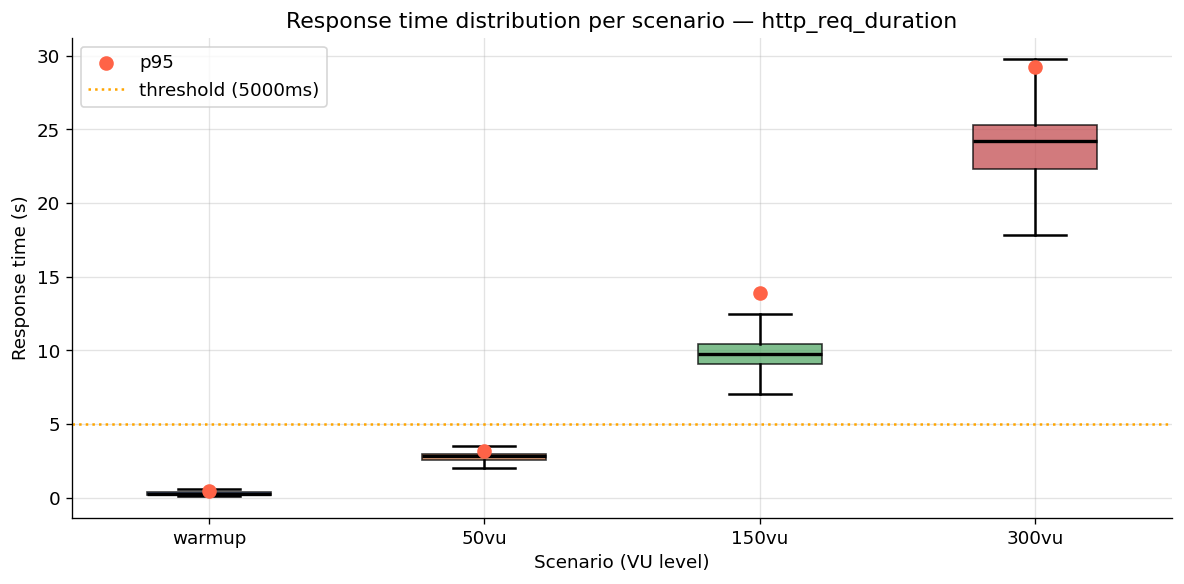

Saved → results/20260310_210727_stress/05_newsfeed_algorithms_boxplot_per_scenario.png


In [29]:
# -- Plot 4: Per-scenario box plots --------------------------------------------

if df_dur.empty:
    print("No duration data — set RAW_FILE and re-run.")
else:
    df_plot = df_dur[~df_dur["scenario"].isin(["setup", "teardown", ""])].copy()
    df_plot["value_s"] = df_plot["value_ms"] / 1000
    sc_order = df_plot.groupby("scenario")["t"].min().sort_values().index.tolist()
    groups = [df_plot[df_plot["scenario"] == sc]["value_s"].values for sc in sc_order]
    sc_labels = [s.split("_")[-1] for s in sc_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(
        groups,
        labels=sc_labels,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
    )
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    for i, sc in enumerate(sc_order, 1):
        vals = df_plot[df_plot["scenario"] == sc]["value_s"].values
        ax.scatter(
            i,
            np.percentile(vals, 95),
            color="tomato",
            zorder=5,
            s=60,
            label="p95" if i == 1 else "",
        )

    if thresh_val:
        ax.axhline(
            thresh_val / 1000,
            color="orange",
            lw=1.5,
            linestyle=":",
            label=f"threshold ({thresh_val}ms)",
        )

    ax.set_xlabel("Scenario (VU level)")
    ax.set_ylabel("Response time (s)")
    ax.set_title(f"Response time distribution per scenario — {PRIMARY_METRIC}")
    ax.legend()
    plt.tight_layout()
    out_path2 = Path(str(RAW_FILE)).parent / f"{bench_key}_boxplot_per_scenario.png"
    plt.savefig(out_path2, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path2}")

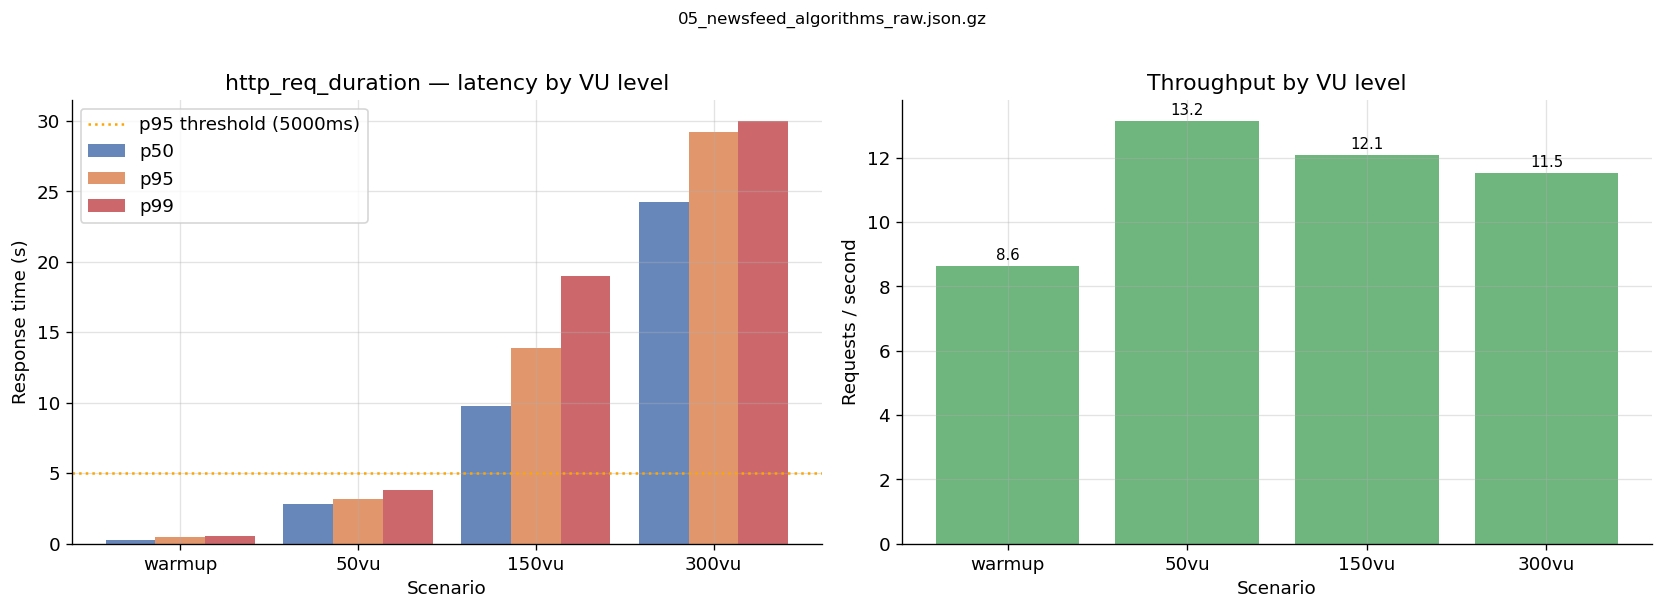

Saved → results/20260310_210727_stress/05_newsfeed_algorithms_per_scenario_bars.png



,scenario,n,p50 (s),p95 (s),p99 (s),req/s
0,warmup,255,0.265,0.463,0.551,8.628
1,50vu,1347,2.785,3.188,3.826,13.156
2,150vu,1407,9.755,13.919,18.964,12.096
3,300vu,1245,24.235,29.214,30.012,11.541


In [30]:
# -- Plot 5: p50 / p95 / p99 bar chart per scenario + throughput ---------------

if df_dur.empty:
    print("No duration data — set RAW_FILE and re-run.")
else:
    df_plot = df_dur[~df_dur["scenario"].isin(["setup", "teardown", ""])].copy()
    sc_order = df_plot.groupby("scenario")["t"].min().sort_values().index.tolist()

    stats = []
    for sc in sc_order:
        vals = df_plot[df_plot["scenario"] == sc]["value_ms"].values
        sc_dur = df_dur[df_dur["scenario"] == sc]
        t_span = (sc_dur["t"].max() - sc_dur["t"].min()) or 1
        stats.append(
            {
                "scenario": sc,
                "label": sc.split("_")[-1],
                "p50": np.percentile(vals, 50) / 1000,
                "p95": np.percentile(vals, 95) / 1000,
                "p99": np.percentile(vals, 99) / 1000,
                "rps": len(vals) / t_span,
                "n": len(vals),
            }
        )
    df_stats = pd.DataFrame(stats)

    x = np.arange(len(df_stats))
    w = 0.28
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(x - w, df_stats["p50"], w, label="p50", color=PALETTE[0], alpha=0.85)
    ax1.bar(x, df_stats["p95"], w, label="p95", color=PALETTE[1], alpha=0.85)
    ax1.bar(x + w, df_stats["p99"], w, label="p99", color=PALETTE[3], alpha=0.85)
    if thresh_val:
        ax1.axhline(
            thresh_val / 1000,
            color="orange",
            lw=1.5,
            linestyle=":",
            label=f"p95 threshold ({thresh_val}ms)",
        )
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_stats["label"])
    ax1.set_ylabel("Response time (s)")
    ax1.set_xlabel("Scenario")
    ax1.set_title(f"{PRIMARY_METRIC} — latency by VU level")
    ax1.legend()

    ax2.bar(x, df_stats["rps"], color=PALETTE[2], alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_stats["label"])
    ax2.set_ylabel("Requests / second")
    ax2.set_xlabel("Scenario")
    ax2.set_title("Throughput by VU level")
    for i, row in df_stats.iterrows():
        ax2.text(
            i,
            row["rps"] + 0.1,
            f"{row['rps']:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.suptitle(f"{Path(str(RAW_FILE)).name}", fontsize=10, y=1.01)
    plt.tight_layout()
    out_path3 = Path(str(RAW_FILE)).parent / f"{bench_key}_per_scenario_bars.png"
    plt.savefig(out_path3, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path3}")

    print()
    display(
        df_stats[["label", "n", "p50", "p95", "p99", "rps"]]
        .rename(
            columns={
                "label": "scenario",
                "p50": "p50 (s)",
                "p95": "p95 (s)",
                "p99": "p99 (s)",
                "rps": "req/s",
            }
        )
        .round(3)
    )

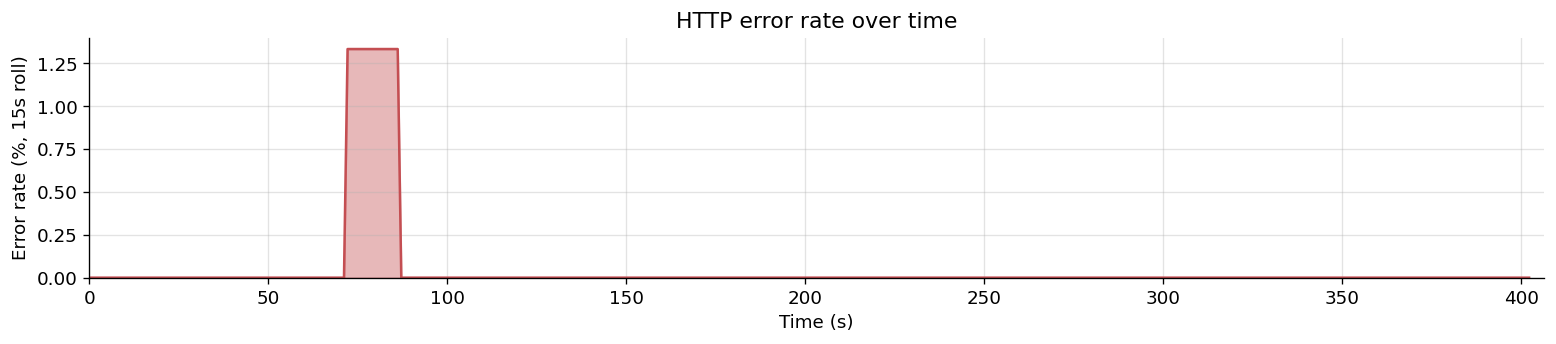

In [31]:
# -- Plot 6: Error rate over time ----------------------------------------------

if df_fail.empty:
    print("No failure data (or no errors recorded — that is fine).")
else:
    t0_f = df_dur["ts"].min() if not df_dur.empty else df_fail["ts"].min()
    df_fail["t"] = (df_fail["ts"] - t0_f).dt.total_seconds()

    df_fail_ts = df_fail.set_index("ts").sort_index()
    roll_err = df_fail_ts["failed"].resample("1s").mean().rolling("15s").mean() * 100
    err_t = [(ts - t0_f).total_seconds() for ts in roll_err.index]

    fig, ax = plt.subplots(figsize=(13, 3))
    ax.fill_between(err_t, roll_err, alpha=0.4, color=PALETTE[3])
    ax.plot(err_t, roll_err, color=PALETTE[3], lw=1.5)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Error rate (%, 15s roll)")
    ax.set_title("HTTP error rate over time")
    ax.set_ylim(bottom=0)
    if not df_dur.empty:
        ax.set_xlim(0, df_dur["t"].max() * 1.01)
    plt.tight_layout()
    plt.show()


# ---
# ## Section 2b — System metrics: CPU, memory, and DB connections over time
#
# Requires a `*_sysmetrics.csv` produced by `collect_sysmetrics.sh` (written
# automatically by the runner scripts alongside the `_raw.json.gz`).
#
# Set `SYSMETRICS_FILE` in the Configuration cell above.
#
# ### What this shows
# - **Panel 1**: CPU % per container (backend, db, redis) over time
# - **Panel 2**: Memory usage (MB) per container over time, with limit as dashed line
# - **Panel 3**: Active DB connections (`pg_stat_activity`) over time
# All panels share the time axis and carry scenario shading from Section 2.

In [32]:
# -- Load sysmetrics CSV -------------------------------------------------------


def load_sysmetrics(path):
    """
    Parse the CSV written by collect_sysmetrics.sh.
    Returns:
      df_sys  — container CPU/mem rows (columns: ts_unix, container, cpu_pct, mem_mb, mem_limit_mb)
      df_pg   — pg_stat_activity active connection count rows (columns: ts_unix, connections)
    """
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(), pd.DataFrame()

    rows = []
    pg_rows = []

    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ts = int(row["timestamp_unix"])
                ctr = row["container"].strip()
                cpu = float(row["cpu_pct"])
                mem = float(row["mem_mb"])
                mlim = float(row["mem_limit_mb"])
            except (KeyError, ValueError):
                continue

            if ctr == "__pg_conns__":
                pg_rows.append({"ts_unix": ts, "connections": int(cpu)})
            else:
                rows.append(
                    {
                        "ts_unix": ts,
                        "container": ctr,
                        "cpu_pct": cpu,
                        "mem_mb": mem,
                        "mem_limit_mb": mlim,
                    }
                )

    df_sys = pd.DataFrame(rows)
    df_pg = pd.DataFrame(pg_rows)
    if not df_sys.empty:
        df_sys = df_sys.sort_values("ts_unix").reset_index(drop=True)
    if not df_pg.empty:
        df_pg = df_pg.sort_values("ts_unix").reset_index(drop=True)
    return df_sys, df_pg


if SYSMETRICS_FILE is None or not Path(SYSMETRICS_FILE).exists():
    print("SYSMETRICS_FILE not set or not found — skipping Section 2b.")
    print("Re-run the benchmark with the updated runner to get a _sysmetrics.csv file.")
    df_sys = pd.DataFrame()
    df_pg = pd.DataFrame()
else:
    print(f"Loading {SYSMETRICS_FILE} …")
    df_sys, df_pg = load_sysmetrics(SYSMETRICS_FILE)
    containers_found = df_sys["container"].unique().tolist() if not df_sys.empty else []
    print(f"  container rows : {len(df_sys):,}  (containers: {containers_found})")
    print(f"  pg_conns rows  : {len(df_pg):,}")

SYSMETRICS_FILE not set or not found — skipping Section 2b.
Re-run the benchmark with the updated runner to get a _sysmetrics.csv file.


In [33]:
# -- Align sysmetrics to k6 t0 -------------------------------------------------
#
# The sysmetrics CSV uses Unix epoch seconds; the k6 raw data uses ISO-8601.
# Both are aligned to t0 = first k6 duration sample so the axes are comparable.
# If Section 2 was skipped (RAW_FILE not set), t0 = first sysmetrics timestamp.


def short_ctr_name(name):
    for kw in ("backend", "db", "postgres", "redis"):
        if kw in name.lower():
            return kw
    return name.split("-")[-1]


if not df_sys.empty:
    t0_unix = t0.timestamp() if t0 is not None else df_sys["ts_unix"].min()

    df_sys["t"] = df_sys["ts_unix"] - t0_unix
    if not df_pg.empty:
        df_pg["t"] = df_pg["ts_unix"] - t0_unix

    df_sys["ctr_short"] = df_sys["container"].map(short_ctr_name)
    print("Sysmetrics aligned to k6 t0.")
    print(f"  t range (s): {df_sys['t'].min():.0f} → {df_sys['t'].max():.0f}")

In [34]:
# -- Plot 7: CPU %, memory, DB connections, and VU count over time ----------------
#
# Four-panel figure sharing the time axis; scenario shading from Section 2.

CTR_COLORS = {
    "backend": "#4C72B0",
    "db": "#DD8452",
    "postgres": "#DD8452",
    "redis": "#55A868",
}

if df_sys.empty:
    print("No sysmetrics data — set SYSMETRICS_FILE and re-run.")
else:
    ctr_groups = df_sys["ctr_short"].unique().tolist()
    has_pg_plot = not df_pg.empty
    has_vus_plot = not df_vus.empty
    n_panels = 4 if has_pg_plot else 3

    fig = plt.figure(figsize=(15, 4 * n_panels))
    gs = GridSpec(n_panels, 1, figure=fig, hspace=0.12)
    ax_cpu = fig.add_subplot(gs[0])
    ax_mem = fig.add_subplot(gs[1], sharex=ax_cpu)
    ax_pg = fig.add_subplot(gs[2], sharex=ax_cpu) if has_pg_plot else None
    ax_vus = fig.add_subplot(gs[3], sharex=ax_cpu) if has_pg_plot else fig.add_subplot(gs[2], sharex=ax_cpu)

    t_max_sys = df_sys["t"].max()
    xlim_max = (
        max(t_max_sys, df_dur["t"].max() if not df_dur.empty else t_max_sys) * 1.01
    )

    def shade_scenarios(ax):
        for sc, (ts, te) in sc_spans.items():
            ax.axvspan(ts, te, alpha=0.07, color=sc_color.get(sc, "#cccccc"))

    # -- CPU % panel --
    shade_scenarios(ax_cpu)
    for ctr in ctr_groups:
        sub = df_sys[df_sys["ctr_short"] == ctr].sort_values("t")
        color = CTR_COLORS.get(ctr, "#937860")
        ax_cpu.plot(sub["t"], sub["cpu_pct"], lw=1.5, label=ctr, color=color, alpha=0.9)
    ax_cpu.set_ylabel("CPU %")
    ax_cpu.set_title(f"System metrics — {Path(str(SYSMETRICS_FILE)).name}")
    ax_cpu.legend(loc="upper left", fontsize=9)
    ax_cpu.set_ylim(bottom=0)
    plt.setp(ax_cpu.get_xticklabels(), visible=False)
    for sc, (ts, te) in sc_spans.items():
        ax_cpu.text(
            (ts + te) / 2,
            ax_cpu.get_ylim()[1] * 0.97,
            sc.split("_")[-1],
            ha="center",
            va="top",
            fontsize=8,
            color=sc_color.get(sc, "#444444"),
            fontweight="bold",
        )

    # -- Memory panel --
    shade_scenarios(ax_mem)
    for ctr in ctr_groups:
        sub = df_sys[df_sys["ctr_short"] == ctr].sort_values("t")
        color = CTR_COLORS.get(ctr, "#937860")
        ax_mem.plot(sub["t"], sub["mem_mb"], lw=1.5, label=ctr, color=color, alpha=0.9)
        lim_vals = sub[sub["mem_limit_mb"] > 0]["mem_limit_mb"]
        if not lim_vals.empty:
            ax_mem.axhline(
                lim_vals.iloc[0],
                color=color,
                lw=0.8,
                linestyle="--",
                alpha=0.4,
                label=f"{ctr} limit",
            )
    ax_mem.set_ylabel("Memory (MB)")
    ax_mem.legend(loc="upper left", fontsize=9)
    ax_mem.set_ylim(0, 2048)
    plt.setp(ax_mem.get_xticklabels(), visible=False)

    # -- DB connections panel --
    if ax_pg is not None:
        shade_scenarios(ax_pg)
        ax_pg.fill_between(
            df_pg["t"],
            df_pg["connections"],
            alpha=0.5,
            color=CTR_COLORS["db"],
            step="post",
        )
        ax_pg.step(
            df_pg["t"],
            df_pg["connections"],
            color=CTR_COLORS["db"],
            lw=1.5,
            where="post",
            label="active connections",
        )
        ax_pg.set_ylabel("DB connections\n(active)")
        ax_pg.legend(loc="upper left", fontsize=9)
        ax_pg.set_ylim(bottom=0)
        plt.setp(ax_pg.get_xticklabels(), visible=False)

    # -- VU count panel --
    if has_vus_plot:
        shade_scenarios(ax_vus)
        ax_vus.fill_between(
            df_vus["t"], df_vus["vus"], alpha=0.6, color="slategray", step="post"
        )
        ax_vus.step(df_vus["t"], df_vus["vus"], color="slategray", lw=1.5, where="post")
        ax_vus.set_ylabel("VUs")
        patches = [
            mpatches.Patch(color=sc_color[s], alpha=0.5, label=s) for s in scenario_names
        ]
        ax_vus.legend(handles=patches, loc="upper left", fontsize=8)
    else:
        ax_vus.text(0.5, 0.5, "No VU data available", ha="center", va="center", transform=ax_vus.transAxes)
    ax_vus.set_xlabel("Time (s)")

    ax_cpu.set_xlim(0, xlim_max)

    out_sys = Path(str(SYSMETRICS_FILE)).parent / f"{bench_key}_sysmetrics.png"
    plt.savefig(out_sys, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_sys}")

No sysmetrics data — set SYSMETRICS_FILE and re-run.


In [35]:
# -- Plot 8: Combined latency p95 + backend CPU % with VU count -------------------
#
# Overlay the p95 latency (left y-axis) and backend CPU % (right y-axis), plus a
# VU underlay panel so the correlation between load and latency is visible.

if df_dur.empty or df_sys.empty:
    print("Need both RAW_FILE and SYSMETRICS_FILE — skipping combined plot.")
else:
    from matplotlib.lines import Line2D

    backend_sub = df_sys[df_sys["ctr_short"] == "backend"].sort_values("t")

    fig = plt.figure(figsize=(15, 7))
    gs = GridSpec(2, 1, figure=fig, height_ratios=[3, 1], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax_vus = fig.add_subplot(gs[1], sharex=ax1)
    ax2 = ax1.twinx()
    ax2.spines["right"].set_visible(True)
    ax2.spines["top"].set_visible(False)

    for sc, (ts, te) in sc_spans.items():
        ax1.axvspan(ts, te, alpha=0.06, color=sc_color.get(sc, "#cccccc"))

    (l1,) = ax1.plot(
        roll_t,
        [v / 1000 for v in roll_p95],
        color="tomato",
        lw=2,
        label="p95 latency (10s roll)",
    )
    (l2,) = ax2.plot(
        backend_sub["t"],
        backend_sub["cpu_pct"],
        color=CTR_COLORS["backend"],
        lw=1.5,
        alpha=0.8,
        label="backend CPU %",
    )

    legend_lines = [l1, l2]
    legend_labels = [l.get_label() for l in legend_lines]
    if thresh_val:
        ax1.axhline(thresh_val / 1000, color="orange", lw=1.5, linestyle=":")
        legend_lines.append(Line2D([0], [0], color="orange", lw=1.5, linestyle=":"))
        legend_labels.append(f"p95 threshold ({thresh_val}ms)")

    ax1.set_ylabel("p95 Response time (s)", color="tomato")
    ax1.tick_params(axis="y", colors="tomato")
    ax2.set_ylabel("Backend CPU %", color=CTR_COLORS["backend"])
    ax2.tick_params(axis="y", colors=CTR_COLORS["backend"])
    ax2.set_ylim(bottom=0)
    ax1.set_title(f"p95 latency vs backend CPU — {bench_key}")
    ax1.set_xlim(0, df_dur["t"].max() * 1.01)
    ax1.legend(legend_lines, legend_labels, loc="upper left", fontsize=9)
    plt.setp(ax1.get_xticklabels(), visible=False)

    if not df_vus.empty:
        for sc, (ts, te) in sc_spans.items():
            ax_vus.axvspan(ts, te, alpha=0.07, color=sc_color.get(sc, "#cccccc"))
        ax_vus.fill_between(
            df_vus["t"], df_vus["vus"], alpha=0.6, color="slategray", step="post"
        )
        ax_vus.step(df_vus["t"], df_vus["vus"], color="slategray", lw=1.5, where="post")
        ax_vus.set_ylabel("VUs")
        patches = [
            mpatches.Patch(color=sc_color[s], alpha=0.5, label=s) for s in scenario_names
        ]
        ax_vus.legend(handles=patches, loc="upper left", fontsize=8)
    else:
        ax_vus.text(0.5, 0.5, "No VU data available", ha="center", va="center", transform=ax_vus.transAxes)
    ax_vus.set_xlabel("Time (s)")

    out_comb = Path(str(RAW_FILE)).parent / f"{bench_key}_latency_vs_cpu.png"
    plt.savefig(out_comb, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_comb}")


# ---
# ## Section 3 — Multi-run comparison
#
# Compare the same benchmark across multiple runs (e.g. before/after scaling).

Need both RAW_FILE and SYSMETRICS_FILE — skipping combined plot.


In [36]:
# -- Configuration: list of (label, summary_json_path) tuples ------------------
# Example:
#   COMPARE_RUNS = [
#       ("1 worker",  "results/20260310_200640_stress/01_auth_login_summary.json"),
#       ("8 workers", "results/20260315_120000_stress/01_auth_login_summary.json"),
#   ]

COMPARE_RUNS = [
    ("stress run 1", "results/20260310_200640_stress/01_auth_login_summary.json"),
    # add more runs here
]

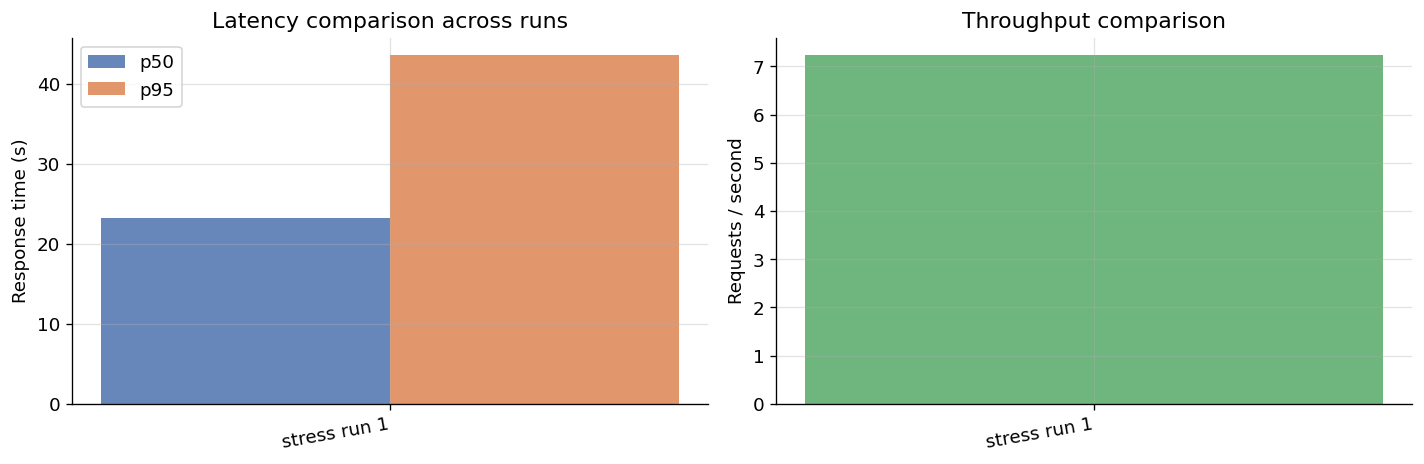

,label,metric,p50,p95,rps
0,stress run 1,login_duration,23.223,43.594,7.236


In [37]:
# -- Plot 9: Multi-run latency comparison --------------------------------------


def load_one_summary(label, path):
    path = Path(path)
    if not path.exists():
        print(f"  Skipping {label} — file not found: {path}")
        return None
    with open(path) as f:
        d = json.load(f)
    metrics = d.get("metrics", {})
    for mname in list(METRIC_MAP.values()) + ["http_req_duration"]:
        if mname in metrics:
            m = metrics[mname]
            return {
                "label": label,
                "metric": mname,
                "p50": m.get("med", 0) / 1000,
                "p95": m.get("p(95)", 0) / 1000,
                "p99": m.get("max", 0) / 1000,
                "rps": metrics.get("http_reqs", {}).get("rate", 0),
            }
    return None


compare_rows = [
    r for r in (load_one_summary(lbl, p) for lbl, p in COMPARE_RUNS) if r is not None
]

if len(compare_rows) < 1:
    print("No comparison data — add entries to COMPARE_RUNS above.")
else:
    df_cmp = pd.DataFrame(compare_rows)
    x = np.arange(len(df_cmp))
    w = 0.28

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(x - w / 2, df_cmp["p50"], w, label="p50", color=PALETTE[0], alpha=0.85)
    ax1.bar(x + w / 2, df_cmp["p95"], w, label="p95", color=PALETTE[1], alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_cmp["label"], rotation=10, ha="right")
    ax1.set_ylabel("Response time (s)")
    ax1.set_title("Latency comparison across runs")
    ax1.legend()

    ax2.bar(x, df_cmp["rps"], color=PALETTE[2], alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_cmp["label"], rotation=10, ha="right")
    ax2.set_ylabel("Requests / second")
    ax2.set_title("Throughput comparison")

    plt.tight_layout()
    plt.show()
    display(df_cmp[["label", "metric", "p50", "p95", "rps"]].round(3))